In [2]:
import pandas as pd

# Load the cleaned TSLA data
tsla_data = pd.read_csv("TSLA_cleaned.csv", index_col="Date", parse_dates=True)

# Use the 'Close' column for forecasting
tsla_close = tsla_data['Close']

# Display the first few rows
print(tsla_data.head())

                Close       High        Low       Open    Volume
Date                                                            
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500
2015-01-09  13.777333  13.998667  13.664000  13.928000  70024500


In [3]:
from sklearn.model_selection import train_test_split

# Define the split ratio (80% train, 20% test)
train_size = int(len(tsla_close) * 0.8)
train, test = tsla_close[:train_size], tsla_close[train_size:]

print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")


Training data points: 2027
Testing data points: 507


Date
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
2015-01-09    13.777333
Name: Close, dtype: float64


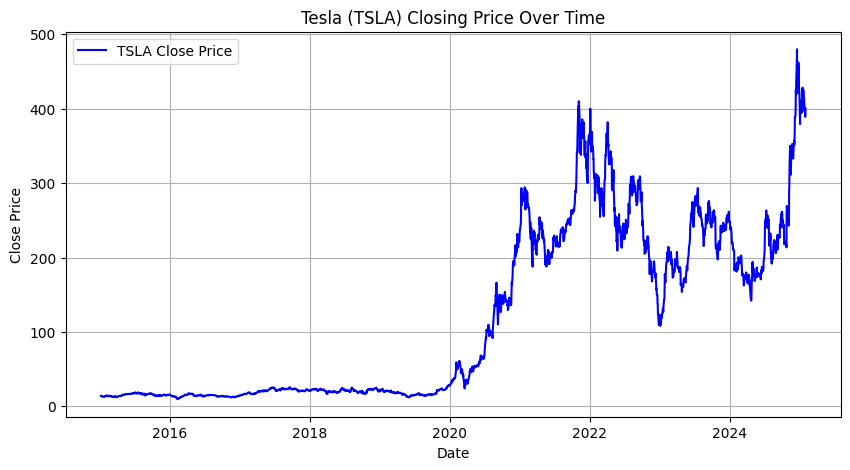

ADF Statistic: -0.5711807147280399
p-value: 0.8773619474292155
Critical Values: {'1%': -3.432962135264372, '5%': -2.862694028699462, '10%': -2.567384333962417}
The time series is non-stationary (p > 0.05). Differencing may be needed.
Training data points: 2027
Testing data points: 507


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split

# Load the cleaned TSLA data
tsla_data = pd.read_csv("TSLA_cleaned.csv", index_col="Date", parse_dates=True)

# Use the 'Close' column for forecasting
tsla_close = tsla_data['Close']

# Display the first few rows
print(tsla_close.head())

# Plot the closing price over time
plt.figure(figsize=(10, 5))
plt.plot(tsla_close, label="TSLA Close Price", color="blue")
plt.title("Tesla (TSLA) Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid()
plt.show()

# Check for stationarity using Augmented Dickey-Fuller test
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] > 0.05:
        print("The time series is non-stationary (p > 0.05). Differencing may be needed.")
    else:
        print("The time series is stationary (p ≤ 0.05). No differencing is required.")

# Run ADF test
adf_test(tsla_close)

# Define the split ratio (80% train, 20% test)
train_size = int(len(tsla_close) * 0.8)
train, test = tsla_close[:train_size], tsla_close[train_size:]

print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")


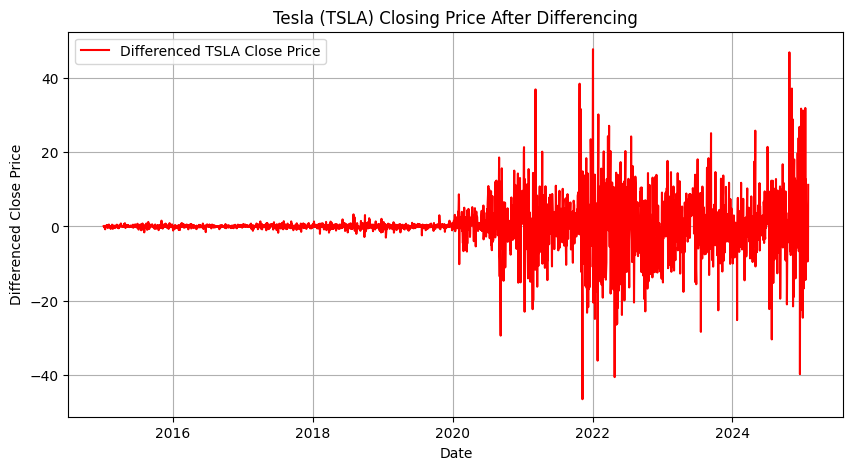

ADF Test After First Differencing:
ADF Statistic: -9.768539323283864
p-value: 7.239575227335158e-17
Critical Values: {'1%': -3.4329631791044304, '5%': -2.8626944896608433, '10%': -2.5673845793841457}
The time series is stationary (p ≤ 0.05). No differencing is required.
Training data points after differencing: 2026
Testing data points after differencing: 507


In [9]:
# Apply first-order differencing
tsla_diff = tsla_close.diff().dropna()

# Plot the differenced series
plt.figure(figsize=(10, 5))
plt.plot(tsla_diff, label="Differenced TSLA Close Price", color="red")
plt.title("Tesla (TSLA) Closing Price After Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Close Price")
plt.legend()
plt.grid()
plt.show()

# Re-run ADF test after differencing
print("ADF Test After First Differencing:")
adf_test(tsla_diff)

# Split data again after differencing
train_size = int(len(tsla_diff) * 0.8)
train_diff, test_diff = tsla_diff[:train_size], tsla_diff[train_size:]

print(f"Training data points after differencing: {len(train_diff)}")
print(f"Testing data points after differencing: {len(test_diff)}")


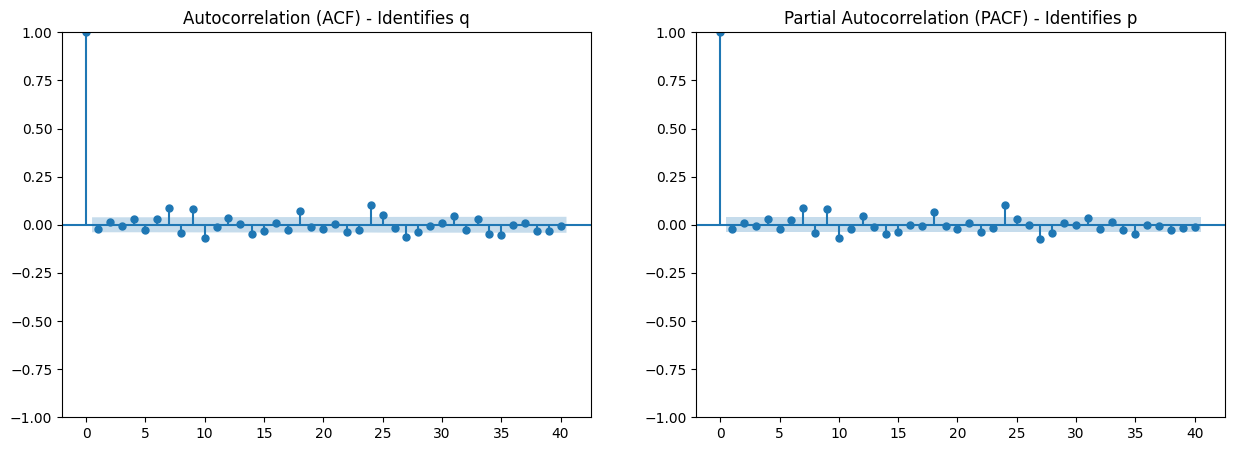

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF to determine p and q
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(tsla_diff, ax=axes[0], lags=40)
axes[0].set_title("Autocorrelation (ACF) - Identifies q")

plot_pacf(tsla_diff, ax=axes[1], lags=40)
axes[1].set_title("Partial Autocorrelation (PACF) - Identifies p")

plt.show()
from statsmodels.tsa.stattools import pacf
# Compute PACF values
pacf_values = pacf(tsla_diff, nlags=40)



In [12]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA(8,1,8) model
model = ARIMA(train, order=(8, 1, 8))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2027
Model:                 ARIMA(8, 1, 8)   Log Likelihood               -6268.798
Date:                Fri, 28 Feb 2025   AIC                          12571.597
Time:                        16:23:34   BIC                          12667.032
Sample:                             0   HQIC                         12606.616
                               - 2027                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1921      0.009    -22.545      0.000      -0.209      -0.175
ar.L2          0.6388      0.009     74.703      0.000       0.622       0.656
ar.L3          0.0462      0.008      5.866      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


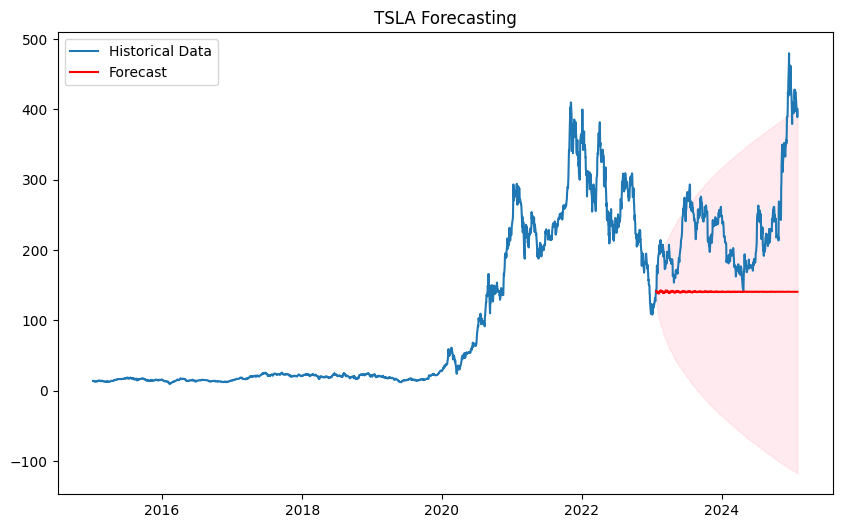

Mean Absolute Error (MAE): 92.99157075594411
Root Mean Squared Error (RMSE): 113.58804322243572


In [13]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate forecast for the testing period
forecast_steps = len(test)
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

# Plot forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(tsla_close.index, tsla_close, label='Historical Data')
plt.plot(test.index, forecast_mean, color='red', label='Forecast')
plt.fill_between(test.index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('TSLA Forecasting')
plt.legend()
plt.show()

# Evaluate performance
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import numpy as np

# Define the grid of parameters to search
p = q = range(0, 5)  # AR and MA order from 0 to 4
d = range(0, 2)  # Differencing orders
P = Q = range(0, 2)  # Seasonal AR and MA orders
D = range(0, 2)  # Seasonal differencing orders
m = [12]  # 12 for yearly seasonality (if data is monthly)

# Create a grid of parameters
param_grid = list(itertools.product(p, d, q, P, D, Q, m))

# Best AIC and parameters initialization
best_aic = np.inf
best_params = None

# Loop through the grid and fit models
for param in param_grid:
    try:
        # Unpack parameters
        p_val, d_val, q_val, P_val, D_val, Q_val, m_val = param

        # Fit SARIMAX model
        model = SARIMAX(tsla_close, order=(p_val, d_val, q_val),
                        seasonal_order=(P_val, D_val, Q_val, m_val),
                        enforce_stationarity=False, enforce_invertibility=False)

        results = model.fit(disp=False)

        # Check if AIC is lower than the best so far
        if results.aic < best_aic:
            best_aic = results.aic
            best_params = param

    except Exception as e:
        # Skip any errors (e.g., convergence issues)
        continue

# Print the best parameters and AIC
print(f"Best Parameters: {best_params}")
print(f"Best AIC: {best_aic}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


KeyboardInterrupt: 

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [6]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 15.5 MB/s eta 0:00:00


In [ ]:
import concurrent.futures
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

# Narrowed down grid (adjust based on what makes sense for your data)
p = q = range(0, 3)  # AR and MA orders from 0 to 2
d = [1]  # Differencing order
P = Q = range(0, 2)  # Seasonal AR and MA orders (0, 1)
D = [1]  # Seasonal differencing order
m = [12]  # 12 for yearly seasonality (assuming monthly data)

param_grid = list(itertools.product(p, d, q, P, D, Q, m))

# Function to fit SARIMAX and return AIC
def fit_sarimax(param):
    try:
        p_val, d_val, q_val, P_val, D_val, Q_val, m_val = param
        model = SARIMAX(tsla_close, order=(p_val, d_val, q_val),
                        seasonal_order=(P_val, D_val, Q_val, m_val),
                        enforce_stationarity=False, enforce_invertibility=False)
        results = model.fit(disp=False, maxiter=100)
        return (param, results.aic)
    except Exception as e:
        return None

# Use concurrent.futures for parallelizing the model fitting
with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = {executor.submit(fit_sarimax, param): param for param in param_grid}

    results = []
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result is not None:
            results.append(result)

# Find the best result based on AIC
best_result = min(results, key=lambda x: x[1])

print(f"Best Parameters: {best_result[0]}")
print(f"Best AIC: {best_result[1]}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [16]:
def fit_sarimax_model(params):
    # Unpack parameters
    p, d, q, P, D, Q = params
    try:
        model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q))
        result = model.fit(disp=False)
        return (params, result.aic)  # Ensure you're returning the parameters and AIC value
    except Exception as e:
        print(f"Error with parameters {params}: {e}")
        return (params, float('inf'))  # Return high AIC for unsuccessful fits


In [17]:
# After running the search
print(f"Best parameters: {best_params}, Best AIC: {best_aic}")


Best parameters: (2, 1, 4, 0, 1, 1, 12), Best AIC: 16421.29907790158


In [18]:
# Fit the final SARIMAX model using the best parameters
best_p, best_d, best_q, best_P, best_D, best_Q, best_s = (2, 1, 4, 0, 1, 1, 12)

# Define the SARIMAX model with the best parameters
final_model = SARIMAX(train,
                      order=(best_p, best_d, best_q),
                      seasonal_order=(best_P, best_D, best_Q, best_s))

# Fit the model
final_result = final_model.fit(disp=False)

# Print the summary of the final model
print(final_result.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                                Close   No. Observations:                 2027
Model:             SARIMAX(2, 1, 4)x(0, 1, [1], 12)   Log Likelihood               -6304.509
Date:                              Fri, 28 Feb 2025   AIC                          12625.019
Time:                                      16:41:12   BIC                          12669.882
Sample:                                           0   HQIC                         12641.486
                                             - 2027                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0463      0.019    -55.784      0.000      -1.083      -1.010
ar.L2         -0.86

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


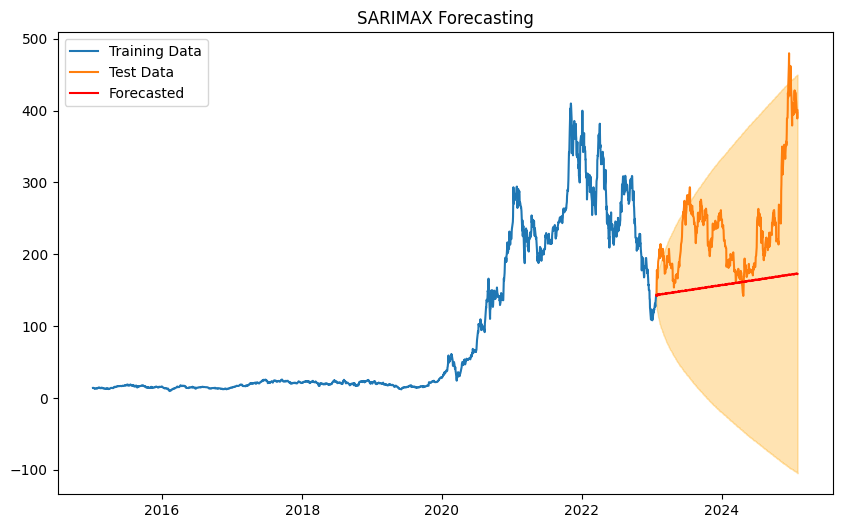

Mean Absolute Error (MAE): 75.79470440408839
Root Mean Squared Error (RMSE): 97.3805716227006


In [19]:
# Forecast using the final model
forecast_steps = len(test)
forecast = final_result.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecasted values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Test Data')
plt.plot(test.index, forecast_mean, label='Forecasted', color='red')
plt.fill_between(test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='orange', alpha=0.3)
plt.legend()
plt.title('SARIMAX Forecasting')
plt.show()

# Evaluate the forecast
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


In [ ]:
import pickle

# Save the model
# Instead of sarimax_model, use final_result which holds the fitted model
with open('sarimax_model.pkl', 'wb') as f:
    pickle.dump(final_result, f)